In [1]:
#!pip install --no-cache-dir torch-scatter -f https://data.pyg.org/whl/torch-2.6.0+cu126.html
#!pip install --no-cache-dir torch-sparse -f https://data.pyg.org/whl/torch-2.6.0+cu126.html
#!pip install --no-cache-dir torch-geometric
#!pip install --no-cache-dir -q git+https://github.com/snap-stanford/deepsnap.git

In [ ]:
#pip install torch-2.3.0-cp310-cp310-linux_aarch64.whl
#pip install torch-scatter torch-sparse torch-cluster torch-spline-conv --no-build-isolation
#python3 -c "import torch; print(f'CUDA available: {torch.cuda.is_available()}'); print(f'Torch version: {torch.__version__}'); print(f'CUDA version: {torch.version.cuda}')"

In [1]:
import networkx as nx
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from dominating_set_algorithms import *

In [2]:
# import required modules
import random
from tqdm import tqdm
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

import torch
from torch import nn, optim, Tensor

from torch_sparse import SparseTensor, matmul

from torch_geometric.utils import structured_negative_sampling
from torch_geometric.data import download_url, extract_zip
from torch_geometric.nn.conv.gcn_conv import gcn_norm
from torch_geometric.nn.conv import MessagePassing
from torch_geometric.typing import Adj


A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.2.6 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "/usr/lib/python3.10/runpy.py", line 196, in _run_module_as_main
    return _run_code(code, main_globals, None,
  File "/usr/lib/python3.10/runpy.py", line 86, in _run_code
    exec(code, run_globals)
  File "/home/jetson/paco/gnn-ds/.venv/lib/python3.10/site-packages/ipykernel_launcher.py", line 18, in <module>
    app.launch_new_instance()
  File "/home/jetson/paco/gnn-ds/.venv/lib/python3.10/site-packages/traitlets/config/application.py", line 1075, in launch_instance
    app.start()
  File "/home/jetson/paco/gnn

In [3]:
import torch
print(torch.__version__)

2.3.0


In [4]:
# setup

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device {device}.")

Using device cuda.


In [5]:
# download the dataset
# url = 'https://files.grouplens.org/datasets/movielens/ml-latest-small.zip'
# extract_zip(download_url(url, '.'), '.')

movie_path = './ml-latest-small/movies.csv'
rating_path = './ml-latest-small/ratings.csv'

#movie_path = './ml-1m/movies.dat'
#rating_path = './ml-1m/ratings.dat'

In [6]:
from data_handling import *

#user_mapping = load_node_csv(rating_path, index_col=0, header=None, delimiter='::', col_names=['movieId', 'rating',	'timestamp'], index_name='userId')
#movie_mapping = load_node_csv(movie_path, index_col=0, header=None, delimiter='::', col_names=['title', 'genres'], index_name='movieId')

user_mapping = load_node_csv(rating_path, index_col='userId')
movie_mapping = load_node_csv(movie_path, index_col='movieId')

In [7]:
for key in movie_mapping:
    movie_mapping[key] += len(user_mapping)

len(user_mapping), len(movie_mapping)

(610, 9742)

In [8]:
import sys
import numpy
import torch

print(f"Python path: {sys.executable}")
print(f"Numpy location: {numpy.__file__}")
print(f"Torch location: {torch.__file__}")

Python path: /home/jetson/paco/gnn-ds/.venv/bin/python
Numpy location: /home/jetson/paco/gnn-ds/.venv/lib/python3.10/site-packages/numpy/__init__.py
Torch location: /home/jetson/paco/gnn-ds/.venv/lib/python3.10/site-packages/torch/__init__.py


In [9]:
edge_index = load_edge_csv(
    rating_path,
    src_index_col='userId',
    src_mapping=user_mapping,
    dst_index_col='movieId',
    dst_mapping=movie_mapping,
    link_index_col='rating',
    rating_threshold=3,
)

edge_index.shape

torch.Size([2, 81763])

# Dominating Sets

In [10]:
# users = ['u' + str(u) for u in edge_index.tolist()[0]]
# items = ['i' + str(i) for i in edge_index.tolist()[1]]

# G = nx.Graph()
# G.add_nodes_from(users, bipartite=0)
# G.add_nodes_from(items, bipartite=1)
# G.add_edges_from(zip(users,items))

# print('Number of nodes: ', G.number_of_nodes())
# print('Number of edges: ', G.number_of_edges())

In [11]:
# dom_set = dominating_set(G,1,optimize=True)

# print('Number of nodes: ', len(dom_set))
# print('Ratio: ', len(dom_set) / G.number_of_nodes())

In [12]:
# ds_users, ds_movies = [], []

# for element in dom_set:
#   if element.startswith('u'):
#     ds_users.append(int(element[1:]))
#   elif element.startswith('i'):
#     ds_movies.append(int(element[1:]))

# len(ds_users), len(ds_movies)

In [13]:
# ds_indices = torch.logical_or(torch.isin(edge_index[0], torch.tensor(ds_users)),
#                               torch.isin(edge_index[1], torch.tensor(ds_movies))).nonzero().reshape(-1).tolist()

# len(ds_indices)

In [14]:
# my_list = ds_indices
# file_name = "c1_indices.txt"

# with open(file_name, 'w') as f:
#     for item in my_list:
#         f.write(f"{item}\n")

In [15]:
def import_txt(file_name):
    with open(file_name, 'r') as file:
        data = file.read().splitlines()
        data = [int(x) for x in data]

        return data

ds_users = import_txt('c1_users.txt')
ds_movies = import_txt('c1_movies.txt')
ds_movies = [x + 6040 for x in ds_movies]
ds_indices = import_txt('c1_indices.txt')

In [16]:
# split the edges of the graph using a 80/10/10 train/validation/test split
num_users, num_movies = len(user_mapping), len(movie_mapping)
num_interactions = edge_index.shape[1]
all_indices = [i for i in range(num_interactions)]

train_indices, test_indices = train_test_split(
    all_indices, test_size=0.2, random_state=1)
val_indices, test_indices = train_test_split(
    test_indices, test_size=0.5, random_state=1)

#train_indices = list(set(train_indices) & set(ds_indices))
#train_indices = random.sample(train_indices, 54402)

train_edge_index = edge_index[:, train_indices]
val_edge_index = edge_index[:, val_indices]
test_edge_index = edge_index[:, test_indices]

train_edge_index.shape

torch.Size([2, 65410])

In [17]:
# convert edge indices into Sparse Tensors: https://pytorch-geometric.readthedocs.io/en/latest/notes/sparse_tensor.html
train_sparse_edge_index = SparseTensor(row=torch.cat([train_edge_index[0],train_edge_index[1]]), 
                                       col=torch.cat([train_edge_index[1],train_edge_index[0]]), 
                                       sparse_sizes=(num_users + num_movies, num_users + num_movies))
val_sparse_edge_index = SparseTensor(row=torch.cat([val_edge_index[0],val_edge_index[1]]), 
                                     col=torch.cat([val_edge_index[1],val_edge_index[0]]), 
                                     sparse_sizes=(num_users + num_movies, num_users + num_movies))
test_sparse_edge_index = SparseTensor(row=torch.cat([test_edge_index[0],test_edge_index[1]]), 
                                      col=torch.cat([test_edge_index[1],test_edge_index[0]]), 
                                     sparse_sizes=(num_users + num_movies, num_users + num_movies))

In [18]:
# define constants
from gcn_model import *
#import optuna

model = LightGCN(num_users, num_movies)

#study = optuna.load_study(study_name="c3dsOpt", storage="sqlite:///db.sqlite3")
#best_params = study.best_params

#ITERATIONS = 10000
#BATCH_SIZE = 1024
#LR = best_params['lr']
#ITERS_PER_EVAL = 200
#ITERS_PER_LR_DECAY = 200
#K = 20
#LAMBDA = best_params['lambda_val']

ITERATIONS = 10000
BATCH_SIZE = 1024
LR = 1e-3
ITERS_PER_EVAL = 200
ITERS_PER_LR_DECAY = 200
K = 20
LAMBDA = 1e-6

optimizer = optim.Adam(model.parameters(), lr=LR)
scheduler = optim.lr_scheduler.ExponentialLR(optimizer, gamma=0.95)

#model = LightGCN(num_users, num_movies, best_params['embedding_dim'], best_params['K'])

In [19]:
import torch
import torch_scatter
import torch_sparse
from torch_geometric.nn import GCNConv

print(f"--- Hardware Check ---")
print(f"Is CUDA available? {torch.cuda.is_available()}")
print(f"GPU Device Name: {torch.cuda.get_device_name(0)}")

print(f"\n--- Library Link Check ---")
# This is the most important part for GNNs
print(f"Torch Scatter CUDA link: {torch.ops.torch_scatter.gather_csr.__module__ == 'torch.ops.torch_scatter'}")

print(f"\n--- Functional Test ---")
# Move a GNN layer to the GPU
try:
    conv = GCNConv(16, 32).to('cuda')
    x = torch.randn(5, 16).to('cuda')
    edge_index = torch.tensor([[0, 1, 1, 2], [1, 0, 2, 1]], dtype=torch.long).to('cuda')
    out = conv(x, edge_index)
    print("✅ GCN Inference on GPU: SUCCESS")
except Exception as e:
    print(f"❌ GNN-GPU Failed: {e}")

--- Hardware Check ---
Is CUDA available? True
GPU Device Name: Orin

--- Library Link Check ---
Torch Scatter CUDA link: False

--- Functional Test ---
✅ GCN Inference on GPU: SUCCESS


In [20]:
# setup
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device {device}.")

model = model.to(device)
model.train()

#optimizer = getattr(optim, best_params['optimizer'])(model.parameters(), lr=LR)
#scheduler = optim.lr_scheduler.ExponentialLR(optimizer, gamma=0.95)

edge_index = edge_index.to(device)
train_edge_index = train_edge_index.to(device)
train_sparse_edge_index = train_sparse_edge_index.to(device)

val_edge_index = val_edge_index.to(device)
val_sparse_edge_index = val_sparse_edge_index.to(device)

train_edge_index_no_offset = train_edge_index.clone().detach()
train_edge_index_no_offset[1] = train_edge_index_no_offset[1] - len(user_mapping)

val_edge_index_no_offset = val_edge_index.clone().detach()
val_edge_index_no_offset[1] = val_edge_index_no_offset[1] - len(user_mapping)

Using device cuda.


In [21]:
import numpy as np
import torch
print(f"NumPy: {np.__version__}") 
print(f"Torch: {torch.__version__}")
print(f"Allocated: {torch.cuda.memory_allocated() / 1024**2:.2f}MB")

NumPy: 2.2.6
Torch: 2.3.0
Allocated: 15.15MB


In [22]:
# training loop
train_losses = []
val_losses = []

for iter in range(ITERATIONS):
    # forward propagation
    users_emb_final, users_emb_0, items_emb_final, items_emb_0 = model.forward(
        train_sparse_edge_index)

    # mini batching
    user_indices, pos_item_indices, neg_item_indices = sample_mini_batch(
        BATCH_SIZE, train_edge_index_no_offset)
    user_indices, pos_item_indices, neg_item_indices = user_indices.to(
        device), pos_item_indices.to(device), neg_item_indices.to(device)
    users_emb_final, users_emb_0 = users_emb_final[user_indices], users_emb_0[user_indices]
    pos_items_emb_final, pos_items_emb_0 = items_emb_final[pos_item_indices], items_emb_0[pos_item_indices]
    neg_items_emb_final, neg_items_emb_0 = items_emb_final[neg_item_indices], items_emb_0[neg_item_indices]

    # loss computation
    train_loss = bpr_loss(users_emb_final, users_emb_0, pos_items_emb_final,
                          pos_items_emb_0, neg_items_emb_final, neg_items_emb_0, LAMBDA)

    optimizer.zero_grad()
    train_loss.backward()
    optimizer.step()

    if iter % ITERS_PER_EVAL == 0:
        model.eval()
        val_loss, recall, precision, ndcg = evaluation(
            model, val_edge_index_no_offset, val_sparse_edge_index, [train_edge_index_no_offset], K, LAMBDA)
        print(f"[Iteration {iter}/{ITERATIONS}] train_loss: {round(train_loss.item(), 5)}, val_loss: {round(val_loss, 5)}, val_recall@{K}: {round(recall, 5)}, val_precision@{K}: {round(precision, 5)}, val_ndcg@{K}: {round(ndcg, 5)}")
        train_losses.append(train_loss.item())
        val_losses.append(val_loss)
        model.train()

    if iter % ITERS_PER_LR_DECAY == 0 and iter != 0:
        scheduler.step()

[Iteration 0/10000] train_loss: -0.69223, val_loss: -0.68716, val_recall@20: 0.00211, val_precision@20: 0.00145, val_ndcg@20: 0.00182
[Iteration 200/10000] train_loss: -5.57215, val_loss: -4.63824, val_recall@20: 0.07296, val_precision@20: 0.03654, val_ndcg@20: 0.06444
[Iteration 400/10000] train_loss: -24.00853, val_loss: -19.69343, val_recall@20: 0.09001, val_precision@20: 0.04378, val_ndcg@20: 0.08164
[Iteration 600/10000] train_loss: -51.74564, val_loss: -42.08717, val_recall@20: 0.11097, val_precision@20: 0.05119, val_ndcg@20: 0.08841
[Iteration 800/10000] train_loss: -81.47958, val_loss: -69.0345, val_recall@20: 0.10642, val_precision@20: 0.0517, val_ndcg@20: 0.08765
[Iteration 1000/10000] train_loss: -121.36292, val_loss: -99.72665, val_recall@20: 0.11241, val_precision@20: 0.05315, val_ndcg@20: 0.09334
[Iteration 1200/10000] train_loss: -164.63919, val_loss: -135.04619, val_recall@20: 0.11768, val_precision@20: 0.05562, val_ndcg@20: 0.10037
[Iteration 1400/10000] train_loss: -1

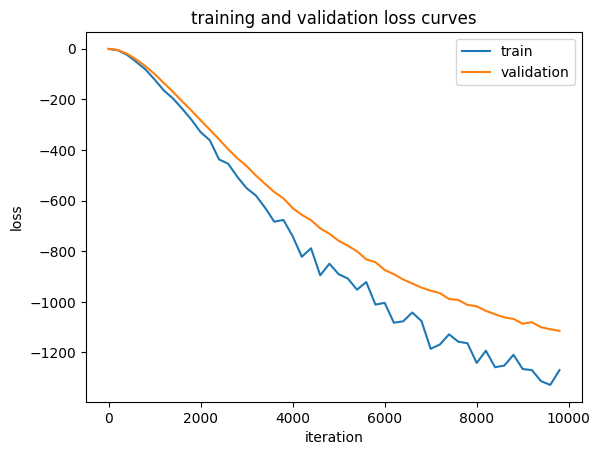

In [23]:
iters = [iter * ITERS_PER_EVAL for iter in range(len(train_losses))]
plt.plot(iters, train_losses, label='train')
plt.plot(iters, val_losses, label='validation')
plt.xlabel('iteration')
plt.ylabel('loss')
plt.title('training and validation loss curves')
plt.legend()
plt.show()

In [27]:
# evaluate on test set
model.eval()

test_edge_index = test_edge_index.to(device)
test_sparse_edge_index = test_sparse_edge_index.to(device)

test_edge_index_no_offset = test_edge_index.clone().detach()
test_edge_index_no_offset[1] = test_edge_index_no_offset[1] - len(user_mapping)

test_loss, test_recall, test_precision, test_ndcg = evaluation(
    model, test_edge_index_no_offset, test_sparse_edge_index, [train_edge_index_no_offset, val_edge_index_no_offset], K, LAMBDA)

print(f"[test_loss: {round(test_loss, 5)}, test_recall@{K}: {round(test_recall, 5)}, test_precision@{K}: {round(test_precision, 5)}, test_ndcg@{K}: {round(test_ndcg, 5)}")

[test_loss: -1113.5365, test_recall@20: 0.12379, test_precision@20: 0.05836, test_ndcg@20: 0.10964


In [24]:
# define constants
import torch
import time
from torch import optim
from gcn_model import *
#import optuna

model = LightGCN(num_users, num_movies)

# --- Hyperparameters & Setup ---
ITERATIONS = 10000
BATCH_SIZE = 1024
LR = 1e-3
ITERS_PER_EVAL = 200
ITERS_PER_LR_DECAY = 200
K_EVAL = 20
LAMBDA = 1e-6

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = model.to(device)

optimizer = optim.Adam(model.parameters(), lr=LR)
scheduler = optim.lr_scheduler.ExponentialLR(optimizer, gamma=0.95)

# Ensure graph data is on GPU
train_sparse_edge_index = train_sparse_edge_index.to(device)
train_edge_index_no_offset = train_edge_index_no_offset.to(device)
val_sparse_edge_index = val_sparse_edge_index.to(device)

# Storage for metrics
train_losses = []
val_metrics = {"loss": [], "recall": [], "precision": [], "ndcg": []}

print(f"Starting Training on {device}...")
start_time = time.time()

for i in range(1, ITERATIONS + 1):
    model.train()
    
    # 1. Forward Pass (Uses the optimized 'Running Sum' if updated in gcn_model.py)
    # This computes embeddings for the entire graph
    u_final, u_0, i_final, i_0 = model(train_sparse_edge_index)

    # 2. Mini-batch Sampling (Pure Torch)
    # We sample 'batch_size' edges and then find a negative item for each
    u_idx, p_idx, n_idx = structured_negative_sampling_torch(
        train_edge_index_no_offset[:, torch.randint(0, train_edge_index_no_offset.size(1), (BATCH_SIZE,))],
        num_nodes=model.num_items
    )

    # 3. Calculate BPR Loss
    # We only take the embeddings for the users/items in our current mini-batch
    loss = bpr_loss(
        u_final[u_idx], u_0[u_idx], 
        i_final[p_idx], i_0[p_idx], 
        i_final[n_idx], i_0[n_idx], 
        LAMBDA
    )

    # 4. Backprop
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    train_losses.append(loss.item())

    # 5. Evaluation Cycle
    if i % ITERS_PER_EVAL == 0:
        model.eval()
        with torch.no_grad(): # Essential to stop memory bloat
            # We use the optimized batched evaluation function
            v_loss, recall, precision, ndcg = evaluation(
                model, 
                val_edge_index_no_offset, 
                val_sparse_edge_index, 
                [train_edge_index_no_offset], 
                K_EVAL, 
                LAMBDA
            )
            
            elapsed = time.time() - start_time
            print(f"Iter {i:05d} | Loss: {loss.item():.4f} | Val Recall@{K_EVAL}: {recall:.4f} | NDCG: {ndcg:.4f} | Time: {elapsed:.1f}s")
            
            val_metrics["loss"].append(v_loss)
            val_metrics["recall"].append(recall)
            
        # Optional: Save best model logic could go here

    # 6. Learning Rate Decay
    if i % ITERS_PER_LR_DECAY == 0:
        scheduler.step()

print("Training Complete.")

Starting Training on cuda...
Iter 00200 | Loss: -5.3663 | Val Recall@20: 0.0802 | NDCG: 0.0632 | Time: 5.4s
Iter 00400 | Loss: -22.5832 | Val Recall@20: 0.0956 | NDCG: 0.0750 | Time: 10.8s
Iter 00600 | Loss: -49.6244 | Val Recall@20: 0.1045 | NDCG: 0.0829 | Time: 16.1s
Iter 00800 | Loss: -86.0805 | Val Recall@20: 0.1117 | NDCG: 0.0905 | Time: 21.5s
Iter 01000 | Loss: -119.6786 | Val Recall@20: 0.1186 | NDCG: 0.0948 | Time: 26.9s
Iter 01200 | Loss: -159.2743 | Val Recall@20: 0.1223 | NDCG: 0.0968 | Time: 32.3s
Iter 01400 | Loss: -199.1385 | Val Recall@20: 0.1237 | NDCG: 0.1009 | Time: 37.7s
Iter 01600 | Loss: -242.8410 | Val Recall@20: 0.1224 | NDCG: 0.1024 | Time: 43.1s
Iter 01800 | Loss: -290.0124 | Val Recall@20: 0.1211 | NDCG: 0.1042 | Time: 48.5s
Iter 02000 | Loss: -327.0136 | Val Recall@20: 0.1204 | NDCG: 0.1032 | Time: 53.9s
Iter 02200 | Loss: -367.3153 | Val Recall@20: 0.1228 | NDCG: 0.1054 | Time: 59.3s
Iter 02400 | Loss: -418.1118 | Val Recall@20: 0.1243 | NDCG: 0.1054 | Time:

# Make New Recommendatios for a Given User

In [ ]:
model.eval()
df = pd.read_csv(movie_path)
movieid_title = pd.Series(df.title.values,index=df.movieId).to_dict()
movieid_genres = pd.Series(df.genres.values,index=df.movieId).to_dict()

user_pos_items = get_user_positive_items(edge_index)

In [67]:
def make_predictions(user_id, num_recs):
    user = user_mapping[user_id]
    e_u = model.users_emb.weight[user]
    scores = model.items_emb.weight @ e_u

    values, indices = torch.topk(scores, k=len(user_pos_items[user]) + num_recs)
    indices += len(user_mapping)

    movies = [index.cpu().item() for index in indices if index in user_pos_items[user]][:num_recs]
    movie_ids = [list(movie_mapping.keys())[list(movie_mapping.values()).index(movie)] for movie in movies]
    titles = [movieid_title[id] for id in movie_ids]
    genres = [movieid_genres[id] for id in movie_ids]

    print(f"Here are some movies that user {user_id} rated highly")
    for i in range(num_recs):
        print(f"title: {titles[i]}, genres: {genres[i]} ")

    print()

    movies = [index.cpu().item() for index in indices if index not in user_pos_items[user]][:num_recs]
    movie_ids = [list(movie_mapping.keys())[list(movie_mapping.values()).index(movie)] for movie in movies]
    titles = [movieid_title[id] for id in movie_ids]
    genres = [movieid_genres[id] for id in movie_ids]

    print(f"Here are some suggested movies for user {user_id}")
    for i in range(num_recs):
        print(f"title: {titles[i]}, genres: {genres[i]} ")

In [68]:
USER_ID = 1
NUM_RECS = 10

make_predictions(USER_ID, NUM_RECS)

Here are some movies that user 1 rated highly
title: Forrest Gump (1994), genres: Comedy|Drama|Romance|War 
title: Silence of the Lambs, The (1991), genres: Crime|Horror|Thriller 
title: Schindler's List (1993), genres: Drama|War 
title: Pulp Fiction (1994), genres: Comedy|Crime|Drama|Thriller 
title: Star Wars: Episode IV - A New Hope (1977), genres: Action|Adventure|Sci-Fi 
title: Jurassic Park (1993), genres: Action|Adventure|Sci-Fi|Thriller 
title: Matrix, The (1999), genres: Action|Sci-Fi|Thriller 
title: Batman (1989), genres: Action|Crime|Thriller 
title: Fugitive, The (1993), genres: Thriller 
title: Braveheart (1995), genres: Action|Drama|War 

Here are some suggested movies for user 1
title: Shawshank Redemption, The (1994), genres: Crime|Drama 
title: Apollo 13 (1995), genres: Adventure|Drama|IMAX 
title: Terminator 2: Judgment Day (1991), genres: Action|Sci-Fi 
title: Aladdin (1992), genres: Adventure|Animation|Children|Comedy|Musical 
title: Good Will Hunting (1997), genre

In [69]:
USER_ID = 414
NUM_RECS = 10

make_predictions(USER_ID, NUM_RECS)

Here are some movies that user 414 rated highly
title: Shawshank Redemption, The (1994), genres: Crime|Drama 
title: Forrest Gump (1994), genres: Comedy|Drama|Romance|War 
title: Silence of the Lambs, The (1991), genres: Crime|Horror|Thriller 
title: Schindler's List (1993), genres: Drama|War 
title: Pulp Fiction (1994), genres: Comedy|Crime|Drama|Thriller 
title: Apollo 13 (1995), genres: Adventure|Drama|IMAX 
title: Terminator 2: Judgment Day (1991), genres: Action|Sci-Fi 
title: Star Wars: Episode IV - A New Hope (1977), genres: Action|Adventure|Sci-Fi 
title: Jurassic Park (1993), genres: Action|Adventure|Sci-Fi|Thriller 
title: Matrix, The (1999), genres: Action|Sci-Fi|Thriller 

Here are some suggested movies for user 414
title: Ace Ventura: Pet Detective (1994), genres: Comedy 
title: Sleepless in Seattle (1993), genres: Comedy|Drama|Romance 
title: Batman Forever (1995), genres: Action|Adventure|Comedy|Crime 
title: Waterworld (1995), genres: Action|Adventure|Sci-Fi 
title: Har

In [70]:
USER_ID = 52
NUM_RECS = 10

make_predictions(USER_ID, NUM_RECS)

Here are some movies that user 52 rated highly
title: Shawshank Redemption, The (1994), genres: Crime|Drama 
title: Forrest Gump (1994), genres: Comedy|Drama|Romance|War 
title: Apollo 13 (1995), genres: Adventure|Drama|IMAX 
title: Star Wars: Episode IV - A New Hope (1977), genres: Action|Adventure|Sci-Fi 
title: Matrix, The (1999), genres: Action|Sci-Fi|Thriller 
title: Aladdin (1992), genres: Adventure|Animation|Children|Comedy|Musical 
title: Good Will Hunting (1997), genres: Drama|Romance 
title: Fight Club (1999), genres: Action|Crime|Drama|Thriller 
title: Star Wars: Episode V - The Empire Strikes Back (1980), genres: Action|Adventure|Sci-Fi 
title: Lord of the Rings: The Return of the King, The (2003), genres: Action|Adventure|Drama|Fantasy 

Here are some suggested movies for user 52
title: Silence of the Lambs, The (1991), genres: Crime|Horror|Thriller 
title: Schindler's List (1993), genres: Drama|War 
title: Pulp Fiction (1994), genres: Comedy|Crime|Drama|Thriller 
title: T